In [ ]:
import pandas as pd
import duckdb
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
PATH = "results"
PROC_DIR = Path(f"../artifacts/{PATH}")
#OUT_PATH = Path(f"output/{'_'.join(PATH.split('/'))}_info.tsv")
#OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
print(PROC_DIR)
files = sorted(PROC_DIR.glob("*_comparison.csv"))
files

In [ ]:
sample = files[0]
sample

In [ ]:
df_results = []
for file in files:
    filename = file.stem
    parts = filename.split("__")
    base = parts[0]
    split = base.split("_")
    stats = {"level": split[1], "grainly": split[2]}
    df = pd.read_csv(file)
    df['level'] = stats['level']
    df['level'] = df['level'].astype(int)
    df['grainly'] = stats['grainly']

    df_results.append(df)

df_results = pd.concat(df_results, ignore_index=True)

# Normalizar ambas a escala 0-1 antes de combinar (más justo si tienen rangos muy distintos)
df_results['wrmsse_norm'] = (df_results['wrmsse'] - df_results['wrmsse'].min()) / (df_results['wrmsse'].max() - df_results['wrmsse'].min())
df_results['fit_time_norm'] = (df_results['fit_time'] - df_results['fit_time'].min()) / (df_results['fit_time'].max() - df_results['fit_time'].min())

df_results['score'] =  (0.8 * df_results['wrmsse_norm'] + 0.2 * df_results['fit_time_norm']) * 100

df_results = df_results.drop(columns=['wrmsse_norm','fit_time_norm'])

df_results.sort_values('score')

In [ ]:
df_mean_level = df_results.groupby(['level']).mean(numeric_only=True).reset_index().round(3)

df_mean_level['models'] =  df_results.groupby(['level'])['model'].nunique().values

df_mean_level

In [ ]:
sns.barplot(df_mean_level, x='level', y='wape')
plt.show()

In [ ]:
sns.barplot(df_mean_level, x='level', y='fit_time')
plt.show()

In [ ]:
sns.barplot(df_mean_level, x='level', y='wrmsse')
plt.axhline(1, color='red', linestyle='--')
plt.show()

# Levels

In [ ]:
levels = df_results['level'].unique()
df_results = df_results.sort_values(['level','category','model'])

def plot_metric_level(metric, df_results=df_results, levels=levels, top=None):
    
    for level in levels:
        df_level = df_results.query(f'level == {level}')[['level','category','model', metric]]
        df_level = df_level.sort_values(metric)
        
        if top:
            df_level = df_level.head(top)
        
        palette = {'Naive': '#55A868', 'ML': '#4C72B0', 'Statistical': '#DD8452'}
        orden = ['ML', 'Naive', 'Statistical']
        
        plt.figure(figsize=(14, 5))
        plt.title(f"nivel={level} metrica={metric}")
        
        sns.barplot(df_level, x='model', y=metric, hue='category', hue_order=orden, palette=palette)
        
        plt.xticks(rotation=45, ha='right')
        
        plt.tight_layout()
        plt.show()

In [ ]:
df_results.columns

In [ ]:
corr = df_results.drop(columns=['level','fit_time']).corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.tight_layout()
plt.show()

In [ ]:
plot_metric_level('wape', top=10)

In [ ]:
plot_metric_level('wape')

In [ ]:
plot_metric_level('wrmsse')

In [ ]:
plot_metric_level('wape')

In [ ]:
plot_metric_level('fit_time')

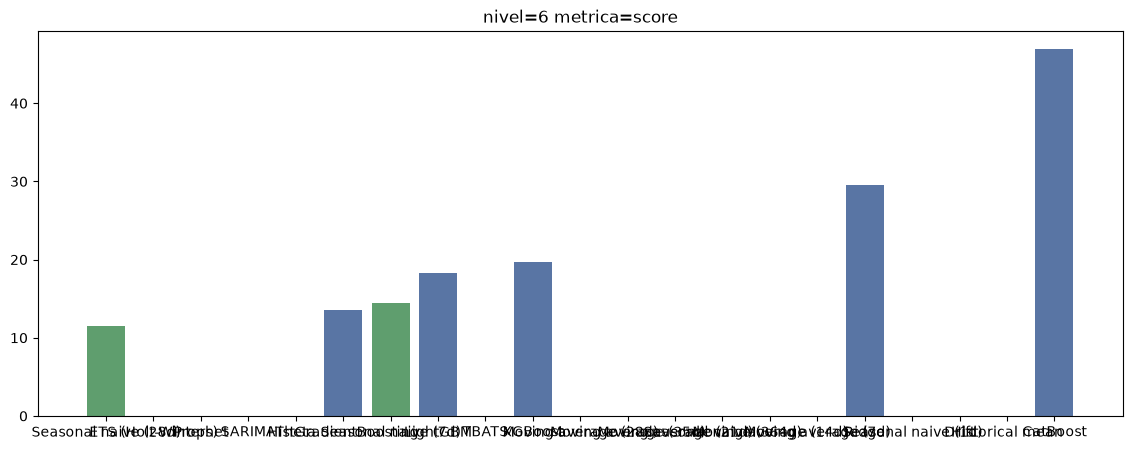

In [ ]:
plot_metric_level('score')